## Datasets & DataLoaders

* Code for processing data samples can get messy and hard to maintain
    * We ideally want our dataset code to be decoupled from our model training code for better readability and modularity
* Pytorch provides two data primitives
    * `torch.utils.data.DataLoader`
        * DataLoader wraps an iterable around the Dataset to enable easy access to the samples
    * `torch.utils.data.Dataset`
        * Dataset stores the samples and their corresponding labels

### Loading a Dataset
* Example of how to load the Fashion-MNIST dataset from TorchVision
    * Fashion-MNIST is a dataset of Zalando’s article images consisting of 60,000 training examples and 10,000 test examples
    * Each example comprises a 28×28 grayscale image and an associated label from one of 10 classes

* parameters
    * `root` is the path where the train/test data is stored
    * `train` specifies training or test dataset
    * `download=True` downloads the data from the internet if it’s not available at `root`
    * `transform` and `target_transform` specify the feature and label transformations

In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100.0%
100.0%
100.0%
100.0%


### Iterating and Visualizing the Dataset
* We can index `Datasets` manually like a list: `train_data[index]`
* Use `matplotlib` to visualize some samples in training data

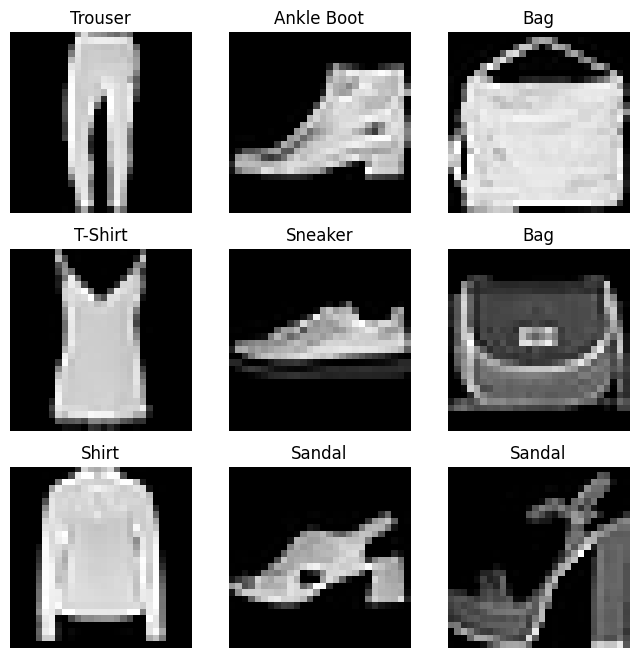

In [2]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]

    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")

plt.show()

### Creating a Custom Dataset for your files
* A custom Dataset class must implement three functions
    * \_\_init__
    * \_\_len__
    * \_\_getitem__
* FashionMNIST images are stored in a directory `img_dir`, and their labels are stored separately in a CSV file `annotations_file`

In [7]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_ir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        
        return image, label

#### \_\_init__
* Run once when instantiating the Dataset object
* We initialize the directory containing the images, the annotations file, and both transforms

The labels.csv file look like  

tshirt1.jpg, 0  
tshirt2.jpg, 0  
......  
ankleboot999.jpg, 9  

In [8]:
def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
    self.img_labels = pd.read_csv(annotations_file)
    self.img_dir = img_dir
    self.transform = transform
    self.target_transform = target_transform

#### \_\_len__
* Returns the number of samples in our dataset

In [9]:
def __len__(self):
    return len(self.img_labels)

#### \_\_getitem__
* Loads and returns a sample from the dataset at the given index `idx`
* Based on th index
* It identifies the image's location on disk
* Convert that to a tensor using `decode_image`
* Retrieves the corresponding label from the csv data in `self.img_labels`
* Calls the transform functions on them(if applicable)
* Returns the tensor image and corresponding lbel in a tuple

In [10]:
def __getitem__(self, idx):
    img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
    image = decode_image(img_path)
    label = self.img_labels.iloc[idx, 1]
    if self.transform:
        image = self.transform(image)
    if self.target_transform:
        label = self.target_transform(label)
    return image, label

### Preparing your data for training with DataLoaders
* `Dataset` retrieves our dataset's features and labels one smaple at a time
* While training a model, we typically want to pass samples in “minibatches”, reshuffle the data at every epoch to reduce model overfitting, and use Python’s `multiprocessing` to speed up data retrieva
* `DataLoader` is an iterable that abstracts this complexity for us in an easy API

In [12]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

### Iterate through the DataLoader
* Each iteration below returns a batch of `train_features` and `train_labels`(containing `batch_size=64` features and labels respectively)
* Because we specified `shuffle=True`, after we iterate over all batches the data is shuffled

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


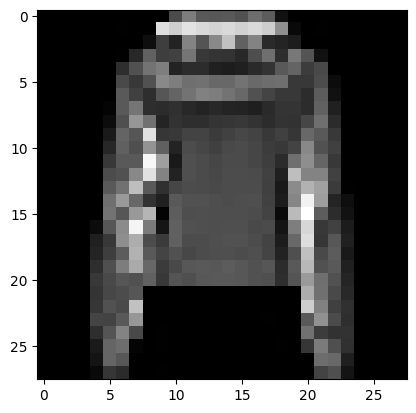

Label: 2


In [17]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")